# 02 — Data quality, coverage, and provenance

**Question.** Before any of the analysis in notebooks 03–05 is trusted: what is
actually in the dataset, where did each number come from, which observations are
provisional, and where do the official and derived figures disagree?

This notebook is deliberately unglamorous. It reads the artefacts, states what
they contain, and records the caveats that the later notebooks rely on.

**Inputs.** `data/processed/portugal_debt_interest.csv` and
`reports/validation.json`, both written by `pt-debt all`.

In [1]:
# Run correctly whether the kernel starts in notebooks/ or the repository root.
# Importing nbtools then puts src/ on the path, so pt_debt_interest is
# importable from a plain checkout without an editable install.
import sys
from pathlib import Path

_HERE = Path.cwd() if (Path.cwd() / "nbtools.py").is_file() else Path.cwd() / "notebooks"
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

import nbtools as nb

nb.use_style()
ROOT = nb.repo_root()

raw = nb.load_dataset(ROOT)
main = nb.main_series(raw)
settings = nb.load_settings(ROOT)

nb.artefact_inventory(ROOT)

,artefact,path,present,size_kb
0,annual dataset,data/processed/portugal_debt_interest.csv,True,145.70
1,sqlite copy,data/processed/portugal_debt_interest.sqlite,True,184.00
2,comparator panel,data/processed/eurostat_panel_metrics.csv,True,"2,946.40"
3,burden decomposition,data/processed/interest_burden_decomposition.csv,True,7.40
4,validation report,reports/validation.json,True,2.90
5,source coverage,reports/source_coverage.csv,True,0.20
6,reproducibility metadata,reports/reproducibility.json,True,0.90
7,summary report,reports/summary.md,True,4.40
8,figure manifest,reports/figures/figures_manifest.csv,True,3.00


## 1. What the table is made of

The dataset deliberately keeps two things apart: the harmonised ESA 2010 series
(Eurostat, 1995 onward) and the linked pre-1995 AMECO extension, which can draw
on ESA 95 and ESA 79 frameworks. A row's `accounting_basis` is what makes that
boundary machine-readable.

In [3]:
composition = (
    raw.groupby(["source", "accounting_basis", "observation_status"])
    .agg(rows=("year", "size"), first_year=("year", "min"), last_year=("year", "max"))
    .astype({"first_year": int, "last_year": int})
)
composition

,,,rows,first_year,last_year
source,accounting_basis,observation_status,,,
Eurostat,ESA2010,observed,31,1995,2025


In [4]:
breaks = raw.loc[raw["basis_break"].astype(str).str.lower().eq("true"), "year"]
print(f"Accounting-basis break flagged at: {[int(year) for year in breaks]}")
print(f"Configured main series start     : {settings.project.main_start_year}")
print(f"Configured extension start       : {settings.project.extended_start_year}")
print(f"Configured end year              : {settings.project.end_year}")

Accounting-basis break flagged at: [1995]
Configured main series start     : 1995
Configured extension start       : 1960
Configured end year              : 2025


## 2. The sample boundary is explicit, not implied

The dataset carries two boolean flags rather than leaving the reader to infer
the sample from the year. `is_harmonised_main_sample` marks the rows that carry
a single ESA 2010 accounting basis; `is_historical_extension` marks any linked
pre-1995 rows drawn from AMECO, which can rest on ESA 95 or ESA 79.

In this build the extension is absent: the pipeline enforces completeness on the
historical extension, and rows that cannot be filled are not emitted rather than
being emitted empty. Everything below, and every analytical statement in the
other notebooks, is the harmonised sample.

In [5]:
sample_flags = pd.DataFrame(
    {
        "rows": [
            int(raw[column].astype(str).str.lower().eq("true").sum())
            for column in ("is_harmonised_main_sample", "is_historical_extension")
        ],
    },
    index=["is_harmonised_main_sample", "is_historical_extension"],
)
sample_flags["share_of_table"] = (sample_flags["rows"] / len(raw)).map("{:.0%}".format)
print(f"Rows in the annual table: {len(raw)}")
sample_flags

Rows in the annual table: 31


,rows,share_of_table
is_harmonised_main_sample,31,100%
is_historical_extension,0,0%


In [6]:
coverage_path = ROOT / "reports" / "source_coverage.csv"
source_coverage = pd.read_csv(coverage_path)
source_coverage

,source,source_database,accounting_basis,observation_status,is_harmonised_main_sample,is_historical_extension,start_year,end_year,row_count,complete_core_rows
0,Eurostat,Eurostat,ESA2010,observed,True,False,1995,2025,31,31


## 2b. Build metadata

`reports/reproducibility.json` records what produced the dataset: the package
version, the interpreter, the configuration hash, and the git revision. A figure
without that context cannot be traced back to a build.

In [7]:
metadata = nb.load_reproducibility(ROOT)
interesting = [
    "generated_at_utc",
    "package_version",
    "python_version",
    "platform",
    "git_commit",
    "git_dirty_tracked_files",
    "config_path",
    "config_sha256",
    "storage_backend",
]
pd.Series(
    {key: metadata.get(key) for key in interesting if key in metadata},
    name="value",
).to_frame()

,value
generated_at_utc,2026-07-28T20:05:04.913829+00:00
package_version,0.1.0
python_version,3.13.5
platform,Windows-11-10.0.26200-SP0
git_commit,8b47152d9b923fc5beb2ea2ba8dac2a0db6ebdbc
git_dirty_tracked_files,True
config_path,config\default.yaml
config_sha256,adf2e6fce2d2e9f46c468ffb691b46557fb178e3d2fec4...
storage_backend,both


## 3. Series availability

The grid below is the honest coverage map for the analytical columns, one cell
per series-year. It is the chart form of the missingness table that follows.

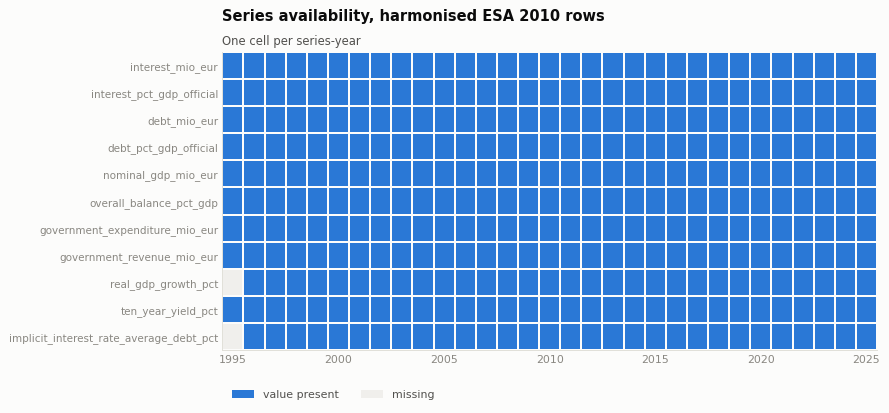

In [8]:
value_columns = [
    "interest_mio_eur",
    "interest_pct_gdp_official",
    "debt_mio_eur",
    "debt_pct_gdp_official",
    "nominal_gdp_mio_eur",
    "overall_balance_pct_gdp",
    "government_expenditure_mio_eur",
    "government_revenue_mio_eur",
    "real_gdp_growth_pct",
    "ten_year_yield_pct",
    "implicit_interest_rate_average_debt_pct",
]
availability = main.set_index("year")[value_columns].notna().T

fig, ax = nb.figure(height=4.4)
ax.pcolormesh(
    np.arange(availability.shape[1] + 1),
    np.arange(availability.shape[0] + 1),
    availability.to_numpy(),
    cmap=ListedColormap(["#f0efec", nb.SERIES[0]]),
    edgecolors=nb.SURFACE,
    linewidth=1.5,
)
ax.set_yticks(np.arange(availability.shape[0]) + 0.5)
ax.set_yticklabels(availability.index, fontsize=8.5)
tick_years = [year for year in availability.columns if year % 5 == 0]
ax.set_xticks([list(availability.columns).index(year) + 0.5 for year in tick_years])
ax.set_xticklabels(tick_years)
ax.invert_yaxis()
ax.grid(False)
ax.legend(
    handles=[
        Patch(facecolor=nb.SERIES[0], label="value present"),
        Patch(facecolor="#f0efec", label="missing"),
    ],
    loc="upper left",
    bbox_to_anchor=(0.0, -0.10),
    ncol=2,
)
nb.finish(
    ax,
    title="Series availability, harmonised ESA 2010 rows",
    subtitle="One cell per series-year",
    source="",
)
plt.show()

In [9]:
missingness = pd.DataFrame(
    {
        "missing_years": [int(main[column].isna().sum()) for column in value_columns],
        "coverage": [f"{main[column].notna().sum()}/{len(main)}" for column in value_columns],
        "first_year_with_data": [
            int(main.loc[main[column].notna(), "year"].min()) if main[column].notna().any() else -1
            for column in value_columns
        ],
    },
    index=value_columns,
)
missingness

,missing_years,coverage,first_year_with_data
interest_mio_eur,0,31/31,1995
interest_pct_gdp_official,0,31/31,1995
debt_mio_eur,0,31/31,1995
debt_pct_gdp_official,0,31/31,1995
nominal_gdp_mio_eur,0,31/31,1995
overall_balance_pct_gdp,0,31/31,1995
government_expenditure_mio_eur,0,31/31,1995
government_revenue_mio_eur,0,31/31,1995
real_gdp_growth_pct,1,30/31,1996
ten_year_yield_pct,0,31/31,1995


The implicit interest rate is missing in the first year by construction, not by
accident: it needs a lagged debt stock, and the pipeline refuses to reach across
the accounting-basis boundary to find one. The same is true of nominal GDP
growth and every debt-dynamics term derived from it.

## 4. The validation report

`pt-debt validate` runs identity and reconciliation checks and writes the result
to `reports/validation.json`. Failures are reported with the years they affect,
and severity separates hard errors from warnings.

In [10]:
report = nb.load_validation(ROOT)
checks = pd.DataFrame(report["checks"])
checks["affected_years"] = checks["affected_years"].apply(
    lambda years: ", ".join(str(int(year)) for year in years) if years else ""
)

print(f"Overall passed: {report['passed']}")
print(f"Checks run    : {len(checks)}")
checks.set_index("name")[["passed", "severity", "affected_years", "detail"]]

Overall passed: True
Checks run    : 13


,passed,severity,affected_years,detail
name,,,,
core_columns_present,True,error,,Missing core columns: []
core_values_present,True,error,,Core columns must not contain missing values.
unique_years,True,error,,Each analytical year must occur once.
provenance_columns_present,True,warning,,Missing provenance columns: []
retrieval_timestamps_present,True,warning,,Source rows should preserve the raw retrieval ...
main_series_year_coverage,True,warning,,Missing years in the harmonised ESA 2010 main ...
interest_ratio_reconciliation,True,warning,,Official and calculated interest ratios differ...
debt_ratio_reconciliation,False,warning,"1997, 1998",Official and calculated debt ratios differ by ...
primary_balance_identity,True,error,,Primary balance must equal overall balance plu...


In [11]:
failed = checks.loc[~checks["passed"]]
if failed.empty:
    print("No failing checks.")
else:
    for _, row in failed.iterrows():
        print(f"[{row['severity']}] {row['name']}: {row['detail']}")
        print(f"    years: {row['affected_years'] or 'n/a'}")

[warning] debt_ratio_reconciliation: Official and calculated debt ratios differ by more than 0.15 pp.
    years: 1997, 1998


## 5. Official versus calculated ratios

Eurostat publishes the ratios directly, and the pipeline also recomputes them
from the levels. Both are kept so the two can be reconciled rather than one
silently replacing the other. The tolerance band is the configured
`analysis.ratio_tolerance_pp`.

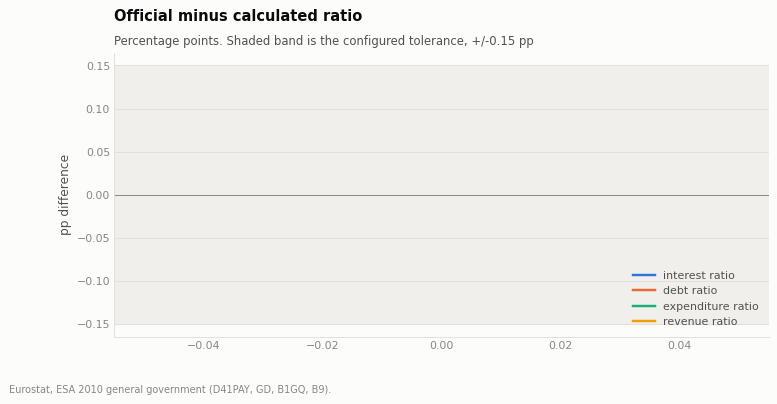

,interest ratio,debt ratio,expenditure ratio,revenue ratio
year,,,,


In [12]:
tolerance = settings.analysis.ratio_tolerance_pp
ratio_pairs = {
    "interest ratio": ("interest_pct_gdp_official", "interest_pct_gdp_calculated"),
    "debt ratio": ("debt_pct_gdp_official", "debt_pct_gdp_calculated"),
    "expenditure ratio": (
        "government_expenditure_pct_gdp_official",
        "government_expenditure_pct_gdp_calculated",
    ),
    "revenue ratio": (
        "government_revenue_pct_gdp_official",
        "government_revenue_pct_gdp_calculated",
    ),
}
reconciliation = pd.DataFrame(
    {
        label: main[official] - main[calculated]
        for label, (official, calculated) in ratio_pairs.items()
        if official in main.columns and calculated in main.columns
    },
    index=main["year"],
)

fig, ax = nb.figure(height=4.2)
for position, column in enumerate(reconciliation.columns):
    ax.plot(
        reconciliation.index,
        reconciliation[column],
        color=nb.SERIES[position],
        label=column,
    )
ax.axhspan(-tolerance, tolerance, color="#f0efec", zorder=0)
ax.axhline(0, color=nb.MUTED, linewidth=0.8, zorder=1)
ax.legend(loc="lower right")
nb.finish(
    ax,
    title="Official minus calculated ratio",
    subtitle=(f"Percentage points. Shaded band is the configured tolerance, +/-{tolerance} pp"),
    ylabel="pp difference",
)
plt.show()

outside = reconciliation.loc[reconciliation.abs().gt(tolerance).any(axis=1)]
outside

The interest ratio reconciles everywhere. The debt ratio breaches the tolerance
in two late-1990s years, and the gap changes sign between them, so it is not a
one-directional scaling error.

The two figures are not built from the same source: the published ratio comes
from the excessive-deficit-procedure table (`gov_10dd_edpt1`), while the
recomputed ratio divides that table's debt level by GDP from the
national-accounts dataset (`nama_10_gdp`). A revision or vintage difference
between those two datasets is the natural reading, and this notebook does not
try to attribute it further. What matters downstream is the convention: the
published ratio is what `debt_pct_gdp` carries, and the recomputed column is
retained so the disagreement stays visible instead of being smoothed away.

## 6. Which observations are provisional

Row-level Eurostat status flags travel with each series. Anything flagged `p`
is provisional and subject to revision, which is the main reason to re-run the
pipeline rather than treat a committed dataset as final.

In [13]:
status_columns = [
    column
    for column in main.columns
    if column.endswith("_status") and not column.endswith("_ameco")
]
flags = main.set_index("year")[status_columns].dropna(how="all")
flags.columns = [column.replace("_status", "") for column in flags.columns]
flags.tail(12)

,interest_mio_eur,interest_pct_gdp_official,overall_balance_pct_gdp,government_expenditure_mio_eur,government_expenditure_pct_gdp_official,government_revenue_mio_eur,government_revenue_pct_gdp_official,debt_mio_eur,debt_pct_gdp_official,nominal_gdp_mio_eur,real_gdp_growth_pct,ten_year_yield_pct,observation
year,,,,,,,,,,,,,
2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,observed
2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,observed
2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,observed
2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,observed
2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,observed
2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,observed
2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,observed
2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,observed
2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,observed


In [14]:
flagged = main.set_index("year")[status_columns].notna().sum().rename("flagged_years").to_frame()
flagged.index = [column.replace("_status", "") for column in flagged.index]
flagged.loc[flagged["flagged_years"].gt(0)]

,flagged_years
nominal_gdp_mio_eur,2
real_gdp_growth_pct,2
observation,31


## 7. Provenance of the latest row

Every value carries the retrieval timestamp, the SHA-256 of the raw response,
and the raw file it was parsed from. That is what makes a published figure
traceable back to a specific download.

In [15]:
latest = main.iloc[-1]
series_names = [
    "interest_mio_eur",
    "interest_pct_gdp_official",
    "overall_balance_pct_gdp",
    "debt_mio_eur",
    "debt_pct_gdp_official",
    "nominal_gdp_mio_eur",
    "real_gdp_growth_pct",
    "ten_year_yield_pct",
]
provenance = pd.DataFrame(
    {
        "value": [latest.get(name) for name in series_names],
        "status": [latest.get(f"{name}_status") for name in series_names],
        "retrieved_utc": [latest.get(f"{name}_retrieval_timestamp_utc") for name in series_names],
        "raw_file": [latest.get(f"{name}_raw_file") for name in series_names],
    },
    index=series_names,
)
print(f"Provenance for year {int(latest['year'])}")
provenance

Provenance for year 2025


,value,status,retrieved_utc,raw_file
interest_mio_eur,"5,964.50",NaN,20260728T200454Z,eurostat_interest_mio_eur_20260728T200454Z.json
interest_pct_gdp_official,1.90,NaN,20260728T200454Z,eurostat_interest_pct_gdp_official_20260728T20...
overall_balance_pct_gdp,0.70,NaN,20260728T200455Z,eurostat_overall_balance_pct_gdp_20260728T2004...
debt_mio_eur,"275,062.80",NaN,20260728T200458Z,eurostat_debt_mio_eur_20260728T200458Z.json
debt_pct_gdp_official,89.70,NaN,20260728T200458Z,eurostat_debt_pct_gdp_official_20260728T200458...
nominal_gdp_mio_eur,"306,749.60",p,20260728T200459Z,eurostat_nominal_gdp_mio_eur_20260728T200459Z....
real_gdp_growth_pct,1.90,p,20260728T200459Z,eurostat_real_gdp_growth_pct_20260728T200459Z....
ten_year_yield_pct,3.08,NaN,20260728T200500Z,eurostat_ten_year_yield_pct_20260728T200500Z.json


In [16]:
checksums = pd.DataFrame(
    {
        "sha256": [latest.get(f"{name}_source_sha256") for name in series_names],
    },
    index=series_names,
)
checksums["sha256_short"] = checksums["sha256"].astype(str).str[:16] + "..."
checksums[["sha256_short"]]

,sha256_short
interest_mio_eur,a9452eb7ad14bd10...
interest_pct_gdp_official,9ee29811048daf22...
overall_balance_pct_gdp,1310f33b4bc078ef...
debt_mio_eur,e2676571de3f32e3...
debt_pct_gdp_official,948a8162150f6deb...
nominal_gdp_mio_eur,da3cb295712aae6e...
real_gdp_growth_pct,82368d2caea76519...
ten_year_yield_pct,81d6dd0e7064df7a...


## 8. A caveat about the generated report

`reports/summary.md` reports the highest observed interest burden over the rows
that have a *complete* headline set — interest in euros, the interest ratio, the
debt ratio, and the implicit rate. The first year of the harmonised series has
no implicit rate (no lagged debt stock within the same accounting basis), so it
is excluded from that statistic even though it is the true maximum of the
published series.

Both numbers are correct for what they measure. The check below makes the
difference explicit so neither is quoted as the other.

In [17]:
headline_columns = [
    "interest_mio_eur",
    "interest_pct_gdp",
    "debt_pct_gdp",
    "implicit_interest_rate_average_debt_pct",
]
observed_rows = nb.observed(main)
complete_rows = observed_rows.dropna(subset=headline_columns)

full_max = observed_rows.loc[observed_rows["interest_pct_gdp"].idxmax()]
complete_max = complete_rows.loc[complete_rows["interest_pct_gdp"].idxmax()]

pd.DataFrame(
    {
        "definition": [
            "max over all observed rows",
            "max over rows with a complete headline set (used by summary.md)",
        ],
        "year": [int(full_max["year"]), int(complete_max["year"])],
        "interest_pct_gdp": [
            full_max["interest_pct_gdp"],
            complete_max["interest_pct_gdp"],
        ],
    }
).set_index("definition")

,year,interest_pct_gdp
definition,,
max over all observed rows,1995,5.50
max over rows with a complete headline set (used by summary.md),1996,4.80


## 9. Caveats carried into the rest of the analysis

Generated below so the list cannot drift away from the data it describes.

In [18]:
caveats = []
extension_rows = int(sample_flags.loc["is_historical_extension", "rows"])
caveats.append(
    f"Analysis window is {int(main['year'].min())}-{int(main['year'].max())}, "
    f"harmonised ESA 2010 only; historical-extension rows in this build: "
    f"{extension_rows}."
)
caveats.append(
    "Lagged quantities (implicit rate, nominal growth, debt dynamics) are "
    f"undefined in {int(main['year'].min())} and are excluded, not imputed."
)
if not failed.empty:
    for _, row in failed.iterrows():
        caveats.append(
            f"Validation warning '{row['name']}' affects years {row['affected_years'] or 'n/a'}."
        )
provisional = flags.tail(1).dropna(axis=1)
if not provisional.empty:
    caveats.append(
        f"Latest year {int(main['year'].max())} carries provisional flags on: "
        + ", ".join(provisional.columns)
        + "."
    )

for index, caveat in enumerate(caveats, start=1):
    print(f"{index}. {caveat}")

1. Analysis window is 1995-2025, harmonised ESA 2010 only; historical-extension rows in this build: 0.
2. Lagged quantities (implicit rate, nominal growth, debt dynamics) are undefined in 1995 and are excluded, not imputed.
3. Validation warning 'debt_ratio_reconciliation' affects years 1997, 1998.
4. Latest year 2025 carries provisional flags on: nominal_gdp_mio_eur, real_gdp_growth_pct, observation.


**Next.** [03 — debt dynamics and decomposition](03_debt_dynamics_and_decomposition.ipynb)
attributes the movements in the burden to the effective rate, the debt ratio,
and nominal growth.